## **Introduction to Integer Programming and Applications with Julia**

<table>
  <tr>
    <td>Chapter</td>
    <td>4 - Traveling Salesman Problem</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

---

## Exercise 4.1

Consider the following TSP instance, which is based on the dataset [tsp_exercise.h5](data/tsp_exercise.h5).

![Alt text](images/Chapter4-exercises.png)

### a) Formulate and solve the TSP without subtour elimination constraints (Section 4.3).

In [1]:
using JuMP  # Modeling language
using HiGHS # Solver
using HDF5  # For reading HDF5 files

# Load utility functions for plotting
include("utils/tsp_utils.jl")

# Function to solve the TSP without subtour elimination constraints
function solve_tsp_no_subtour(file_path)
    # Load the distance matrix from the HDF5 file
    D = h5read(file_path, "distance_matrix")

    # Number of locations
    n = size(D, 1)

    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n, 1:n], Bin)

    # Objective function: minimize total distance
    @objective(model, Min, sum(D[i, j] * x[i, j] for i in 1:n, j in 1:n))

    # Constraints: no self-loops
    @constraint(model, [i=1:n], x[i, i] == 0)                 

    # Constraints: each location visited once
    @constraint(model, [j=1:n], sum(x[i, j] for i in 1:n) == 1)

    # Constraints: each location departed once
    @constraint(model, [i=1:n], sum(x[i, j] for j in 1:n) == 1)

    # Solve
    JuMP.optimize!(model)

    # Get the values of the decision variables
    x_opt = JuMP.value.(x)

    # Extract the routes from the solution
    visited = fill(false, n)
    routes = Vector{Vector{Int}}()
    for start in 1:n
        if !visited[start]
            route = Int[start]
            visited[start] = true
            nxt = findfirst(x_opt[start, :] .> 0.5)
            while nxt !== nothing && !visited[nxt]
                push!(route, nxt)
                visited[nxt] = true
                nxt = findfirst(x_opt[nxt, :] .> 0.5)
            end
            push!(routes, route)
            println("Route: ", route)
        end
    end

    # Get the optimal value of the objective function
    z_opt = JuMP.objective_value(model)
    println("Optimal value: $z_opt meters")

    # Plot the solution on the map
    fmap = plot_tsp_solution(file_path, x_opt)
    display(fmap)
    fmap.save("tsp_solution_no_subtour.html")
end

# Example usage
solve_tsp_no_subtour("data/tsp_exercise.h5")

Route: [1, 6, 2]
Route: [3, 8, 5]
Route: [4, 7]
Optimal value: 3240.8 meters


Python: <folium.folium.Map object at 0x7fc13b3df770>

Python: None

### b) Formulate and solve the TSP with Miller-Tucker-Zemlin (Section 4.4).

In [ ]:
using JuMP  # Modeling language
using HiGHS # Solver
using HDF5  # For reading HDF5 files

# Load utility functions for plotting
include("utils/tsp_utils.jl")

# Function to solve the TSP with MTZ subtour elimination constraints
function solve_tsp_mtz(file_path)
    # Load the distance matrix from the HDF5 file
    D = h5read(file_path, "distance_matrix")

    # Number of locations
    n = size(D, 1)

    # Create model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n, 1:n], Bin)

    # Define MTZ variables 
    @variable(model, 1 <= u[1:n] <= n)

    # Objective function: minimize total distance
    @objective(model, Min, sum(D[i,j] * x[i,j] for i in 1:n, j in 1:n))

    # Avoid self-loops
    @constraint(model, [i=1:n], x[i,i] == 0)

    # Each column sums to 1 (each location visited once)
    @constraint(model, [j=1:n], sum(x[i,j] for i in 1:n) == 1)

    # Each row sums to 1 (each location departs once)
    @constraint(model, [i=1:n], sum(x[i,j] for j in 1:n) == 1)

    # Breaking symmetry by fixing the first city as the starting point
    @constraint(model, u[1] == 1)

    # MTZ constraints
    @constraint(model, [i=2:n, j=2:n; i != j], u[j] >= u[i] + 1 + n * (x[i,j] - 1))

    # Run the solver
    JuMP.optimize!(model)

    # Get the values of the decision variables
    x_opt = JuMP.value.(x)

    # Extract the routes from the solution
    route = [1]
    while true
        to = findfirst(x_opt[route[end], :] .> 0.5)
        to == 1 ? break : push!(route, to)
    end
    println("Route: $route")

    # Get the optimal value of the objective function
    z_opt = JuMP.objective_value(model)
    println("Optimal value: $z_opt meters")

    # Plot the solution on the map
    fmap = plot_tsp_solution(file_path, x_opt)
    display(fmap)
end

# Example usage
solve_tsp_mtz("data/tsp_exercise.h5")

Route: [1, 2, 5, 3, 8, 4, 7, 6]
Optimal value: 3693.2999999999984 meters


Python: <folium.folium.Map object at 0x7fc13b2c42d0>

Python: None

### c) Formulate and solve the TSP with lazy constraints (Section 4.5).

In [4]:
using JuMP   # Modeling language
using GLPK   # Solver
using HDF5   # For reading HDF5 files
using Graphs # For graph operations

# Load utility functions for plotting
include("utils/tsp_utils.jl")

# Define lazy constraints callback function
function tsp_lazy_callback(cb_data)
    
    # Get decision variable values
    x_val = [callback_value(cb_data, x[i,j]) for i in 1:n, j in 1:n]

    # Build an undirected graph
    g = Graphs.SimpleGraph(n)
    for i in 1:n, j in 1:n
        if i != j && x_val[i, j] > 0.5
            Graphs.add_edge!(g, i, j)
        end
    end

    # Find connected components
    cc = Graphs.connected_components(g)

    # If there are more than one connected components, we have a subtour
    if length(cc) > 1
        
        # Pick the smallest component (i.e., subtour)
        minTour = sort(cc, by=length)[1]

        # Initialize the left-hand side of the constraint
        subtourLhs = AffExpr()

        # Sum the decision variables corresponding to the subtour edges
        for i in minTour, j in minTour
            if i != j && x_val[i, j] > 0.5
                subtourLhs += x[i, j]
            end
        end

        # Add lazy constraint to eliminate subtour
        constraint = @build_constraint(subtourLhs <= length(minTour) - 1)

        # Print the constraint for debugging
        println("Adding lazy constraint: ", constraint.func, " <= ", constraint.set.upper)

        # Submit the lazy constraint to the model
        JuMP.MOI.submit(model, JuMP.MOI.LazyConstraint(cb_data), constraint)
    end
end

# Load the distance matrix from the HDF5 file
D = h5read("data/tsp_exercise.h5", "distance_matrix")

# Number of locations
n = size(D, 1)

# Create model
model = JuMP.Model(GLPK.Optimizer)

# Silent mode (solver output is not printed)
JuMP.set_silent(model)

# Define the decision variables
@variable(model, x[1:n, 1:n], Bin)

# Objective function: minimize total distance
@objective(model, Min, sum(D[i,j] * x[i,j] for i in 1:n, j in 1:n))

# Constraints to eliminate self-loops
@constraint(model, [i=1:n], x[i,i] == 0)

# Each column sums to 1 (each location visited once)
@constraint(model, [j=1:n], sum(x[i,j] for i in 1:n) == 1)

# Each row sums to 1 (each location departs once)
@constraint(model, [i=1:n], sum(x[i,j] for j in 1:n) == 1)

# Set the lazy constraint callback function to the model
JuMP.MOI.set(model, JuMP.MOI.LazyConstraintCallback(), tsp_lazy_callback)

# Run the solver
JuMP.optimize!(model)

# Get the values of the decision variables
x_opt = JuMP.value.(x)

# Extract the routes from the solution
route = [1]
while true
    to = findfirst(x_opt[route[end], :] .> 0.5)
    to == 1 ? break : push!(route, to)
end
println("Route: $route")

# Get the optimal value of the objective function
z_opt = JuMP.objective_value(model)
println("Optimal value: $z_opt meters")

# Plot the solution on the map
fmap = plot_tsp_solution("data/tsp_exercise.h5", x_opt)
display(fmap)

Adding lazy constraint: x[4,7] + x[7,4] <= 1.0
Adding lazy constraint: x[3,5] + x[5,3] <= 1.0
Adding lazy constraint: x[1,2] + x[2,1] <= 1.0
Route: [1, 2, 5, 3, 8, 4, 7, 6]
Optimal value: 3693.2999999999997 meters


Python: <folium.folium.Map object at 0x7fc13b1a16e0>

#### Discussion:

| Method   | Objective | Solution                     |
|----------|-----------|------------------------------|
| TSP-Rel  | 3240.8    | [1, 6, 2]  [3, 8, 5]  [4, 7] |
| TSP-MTZ  | 3693.30   | [1, 2, 5, 3, 8, 4, 7, 6]     |
| TSP-Lazy | 3693.30   | [1, 2, 5, 3, 8, 4, 7, 6]     |

For TSP-Rel (No Subtour Elimination), the solution consists of multiple disconnected routes (subtours), such as [1, 6, 2], [3, 8, 5], and [4, 7]. The objective value (3240.8) is lower, but this is not a valid TSP tour since it does not visit all cities in a single cycle.

In the TSP-MTZ and TSP-Lazy (With Subtour Elimination) context, both methods yield a single valid tour: [1, 2, 5, 3, 8, 4, 7, 6].
The objective value (3693.30) is higher than the TSP-Rel, but the solution is feasible for the TSP, visiting all cities exactly once in a single cycle.

Subtour elimination constraints are essential in TSP formulations to prevent the occurrence of multiple disconnected cycles (subtours) in the solution. Without these constraints, the solver may find solutions that minimize the total distance but do not form a valid tour, as seen in the TSP-Rel result. Methods like MTZ and Lazy Constraints ensure that the solution is a single tour covering all cities, which is the true requirement of the TSP.

---

## Exercise 4.2

Route: [1, 7, 5, 4, 6, 3, 2]
Optimal value: 22.0 meters


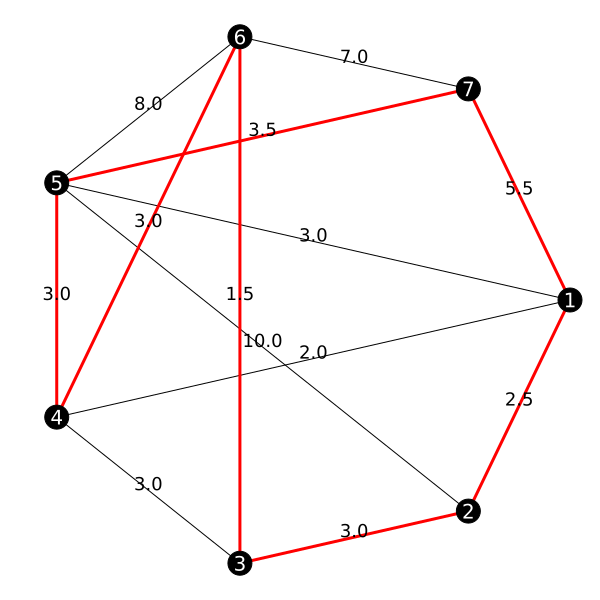

In [4]:
using JuMP                  # Modeling language
using HiGHS                 # Solver
using CSV                   # CSV file handling
using DataFrames            # Dataframe handling
using Graphs                # For graph data structures
using SimpleWeightedGraphs  # For weighted graphs
using Karnak                # For drawing graphs
using Colors                # For color manipulation

# Utility functions for TSP solution plotting
function plot_tsp_solution(graph::SimpleWeightedGraph, x_opt::Matrix{Float64})
    # Extract the route from the solution
    route = [(coord[1], coord[2]) for coord in findall(x_opt .> 0.5)]

    # Define a function to check if an edge is part of the route
    function is_in_route(e, route)
        return (e.src, e.dst) in route || (e.dst, e.src) in route ? true : false
    end

    # Draw graph
    @drawsvg begin
        background("white")
        sethue("black")
        fontsize(20)
        drawgraph(
            graph,
            vertexshapesizes = 12,
            vertexlabels = 1:Graphs.nv(graph),
            edgelabels = [graph.weights[e.src, e.dst] for e in Graphs.edges(graph)],
            edgelabelfontsizes = 18,
            edgestrokecolors = [is_in_route(e, route) ? Colors.RGB(1, 0, 0) : Colors.RGB(0, 0, 0) for e in Graphs.edges(graph)],
            edgestrokeweights = [is_in_route(e, route) ? 3 : 1 for e in Graphs.edges(graph)]
        )
    end
end

# Function to solve TSP using MTZ formulation
function solve_tsp_mtz(file_path)

    # Load the CSV file containing the TSP data
    df = CSV.read(file_path, DataFrame)

    # Load graph
    graph = SimpleWeightedGraph(df.From, df.To, df.Distance)
    
    # Number of vertices
    n = nv(graph)

    # Create model
    model = JuMP.Model(HiGHS.Optimizer)

    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)

    # Define the decision variables
    @variable(model, x[1:n, 1:n], Bin)

    # Define the MTZ variables
    @variable(model, u[2:n])

    # Objective function: minimize total distance
    @objective(model, Min, sum(Graphs.has_edge(graph, i, j) ? graph.weights[i, j] * x[i,j] : floatmax(Float64) * x[i,j] for i in 1:n, j in 1:n))

    # Constraints to eliminate self-loops
    @constraint(model, [i=1:n], x[i,i] == 0)

    # Each column sums to 1 (each location visited once)
    @constraint(model, [j=1:n], sum(x[i,j] for i in 1:n) == 1)

    # Each row sums to 1 (each location departs once)
    @constraint(model, [i=1:n], sum(x[i,j] for j in 1:n) == 1)

    # MTZ constraints
    @constraint(model, [i=2:n, j=2:n], n * x[i,j] - (n - 1) <= u[j] - u[i])

    # Run the solver
    JuMP.optimize!(model)

    # Get the values of the decision variables
    x_opt = JuMP.value.(x)

    # Extract the routes from the solution
    route = [1]
    while true
        to = findfirst(x_opt[route[end], :] .> 0.5)
        to == 1 ? break : push!(route, to)
    end
    println("Route: $route")

    # Get the optimal value of the objective function
    z_opt = JuMP.objective_value(model)
    println("Optimal value: $z_opt meters")

    # Plot the solution on the map
    plot_tsp_solution(graph, x_opt)
end

# Example usage
solve_tsp_mtz("data/tsp_exercise.csv")